In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:

df = pd.read_csv("final_energy_dataset.csv")

In [3]:
df

,Date,Temperature_Mean,Temperature_Max,Precipitation,Sunshine,Wind_Speed,Consumption,Demand,Month
0,01-01-2025,14400.00,2.7,0.0,25.3,28582.70,173243.940,162312.00,1
1,02-01-2025,14400.00,2.6,6.6,19.0,28654.95,183581.907,176485.33,1
2,03-01-2025,13603.61,0.3,1.0,22.3,28732.77,170318.780,168552.00,1
3,04-01-2025,0.00,-1.1,0.3,11.8,28816.05,173695.935,168552.00,1
4,05-01-2025,0.00,-0.1,16.5,12.4,28904.69,176726.706,177862.00,1
...,...,...,...,...,...,...,...,...,...
480,26-04-2026,46086.55,7.4,0.0,6.5,52388.67,173303.086,175320.00,4
481,27-04-2026,50176.30,8.3,0.0,3.4,52606.92,176562.960,175320.00,4
482,28-04-2026,45673.19,9.2,0.0,13.7,52823.15,177132.106,175320.00,4
483,29-04-2026,50622.31,8.1,0.0,14.3,53037.13,177356.770,175320.00,4


In [28]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

In [29]:
df["Demand"] = pd.to_numeric(
    df["Demand"],
    errors="coerce"
)

df["Demand"] = df["Demand"].fillna(
    df["Demand"].mean()
)

In [30]:

df = df.sort_values(by="Date")

In [31]:
df["Lag_1"] = df["Demand"].shift(1)

df["Lag_2"] = df["Demand"].shift(2)

df["Lag_3"] = df["Demand"].shift(3)

In [32]:
df = df.dropna()

In [33]:
X = df[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3"
    ]
]

In [34]:
y = df["Demand"]

In [35]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [36]:
model = RandomForestRegressor(

    n_estimators=300,

    random_state=42

)

In [37]:
model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
y_pred = model.predict(X_test)

In [39]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nMODEL PERFORMANCE")

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R2 Score : {r2:.2f}")


MODEL PERFORMANCE
MAE  : 5377.77
RMSE : 7760.08
R2 Score : 0.61


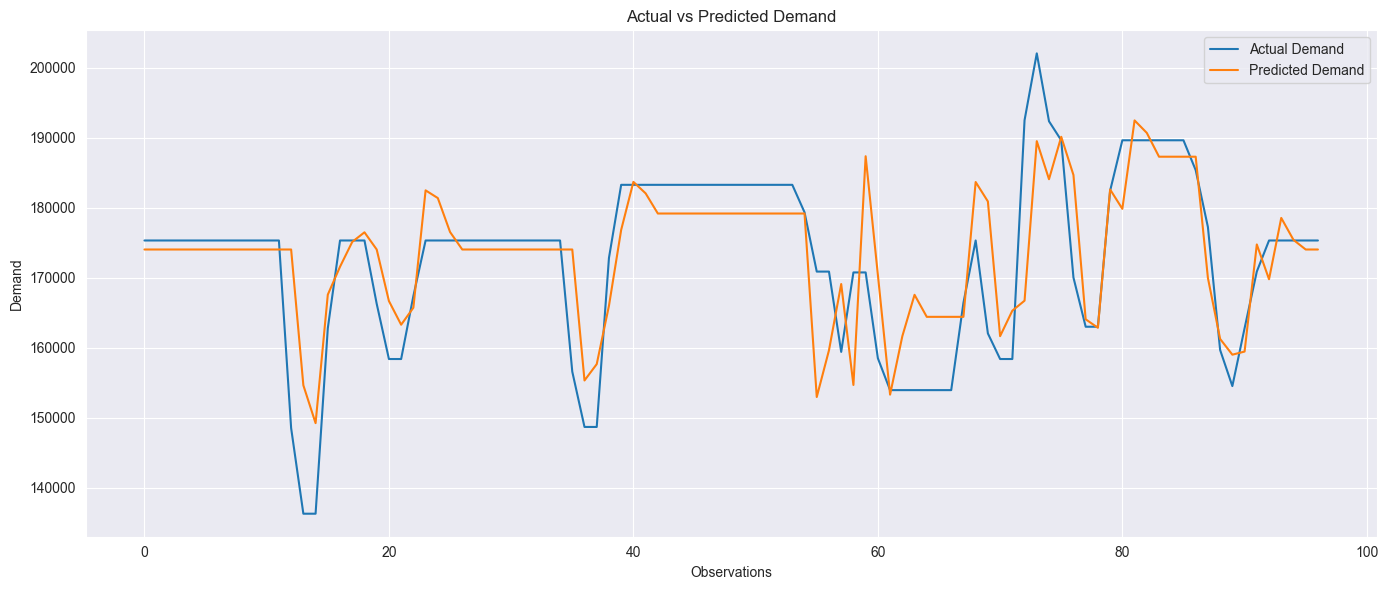

c:\Users\shraddhesh.datkhile\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shraddhesh.datkhile\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shraddhesh.datkhile\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shraddhesh.datkhile\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\shraddhesh.datk


NEXT 3 MONTH FORECAST
         Date  Forecasted_Demand
0  2026-05-01      174033.037482
1  2026-05-02      174510.889704
2  2026-05-03      174402.489704
3  2026-05-04      176801.743777
4  2026-05-05      175460.181830
..        ...                ...
85 2026-07-25      166035.856767
86 2026-07-26      179897.147567
87 2026-07-27      153321.541667
88 2026-07-28      166035.856767
89 2026-07-29      179897.147567

[90 rows x 2 columns]

Forecast Saved Successfully!


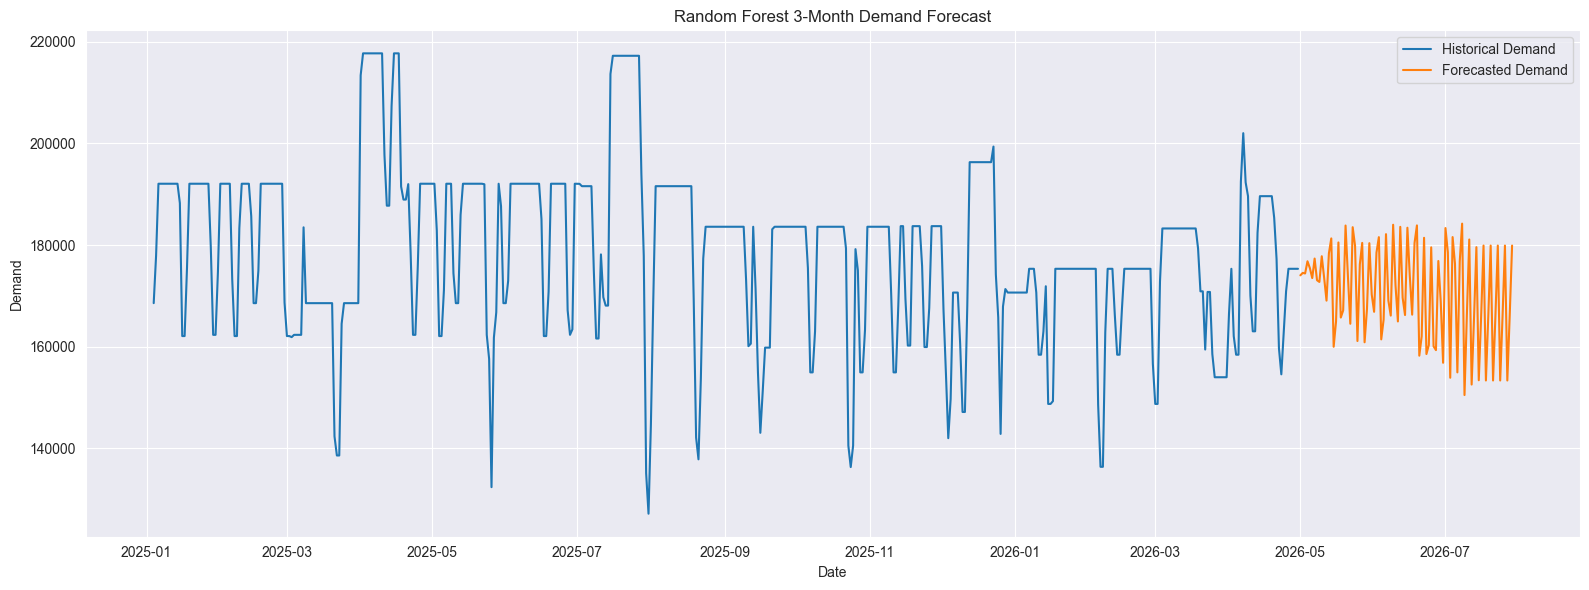

In [40]:
# =========================================================
# ACTUAL VS PREDICTED GRAPH
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    y_pred,
    label="Predicted Demand"
)

plt.title(
    "Actual vs Predicted Demand"
)

plt.xlabel("Observations")

plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# FUTURE FORECASTING
# =========================================================

future_steps = 90

# Last 3 known demand values
last_values = list(
    df["Demand"].tail(3)
)

forecast_values = []

# =========================================================
# GENERATE FUTURE VALUES
# =========================================================

for i in range(future_steps):

    input_data = np.array(last_values[-3:]).reshape(1, -1)

    pred = model.predict(input_data)[0]

    forecast_values.append(pred)

    last_values.append(pred)

# =========================================================
# FUTURE DATES
# =========================================================

future_dates = pd.date_range(

    start=df["Date"].max() + pd.Timedelta(days=1),

    periods=future_steps

)

# =========================================================
# FORECAST DATAFRAME
# =========================================================

forecast_df = pd.DataFrame({

    "Date": future_dates,

    "Forecasted_Demand": forecast_values

})

# =========================================================
# DISPLAY FORECAST
# =========================================================

print("\nNEXT 3 MONTH FORECAST")

print(forecast_df)

# =========================================================
# SAVE FORECAST
# =========================================================

forecast_df.to_csv(

    "random_forest_forecast.csv",

    index=False

)

print("\nForecast Saved Successfully!")

# =========================================================
# FORECAST GRAPH
# =========================================================

plt.figure(figsize=(16,6))

plt.plot(
    df["Date"],
    df["Demand"],
    label="Historical Demand"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Demand"],
    label="Forecasted Demand"
)

plt.title(
    "Random Forest 3-Month Demand Forecast"
)

plt.xlabel("Date")

plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

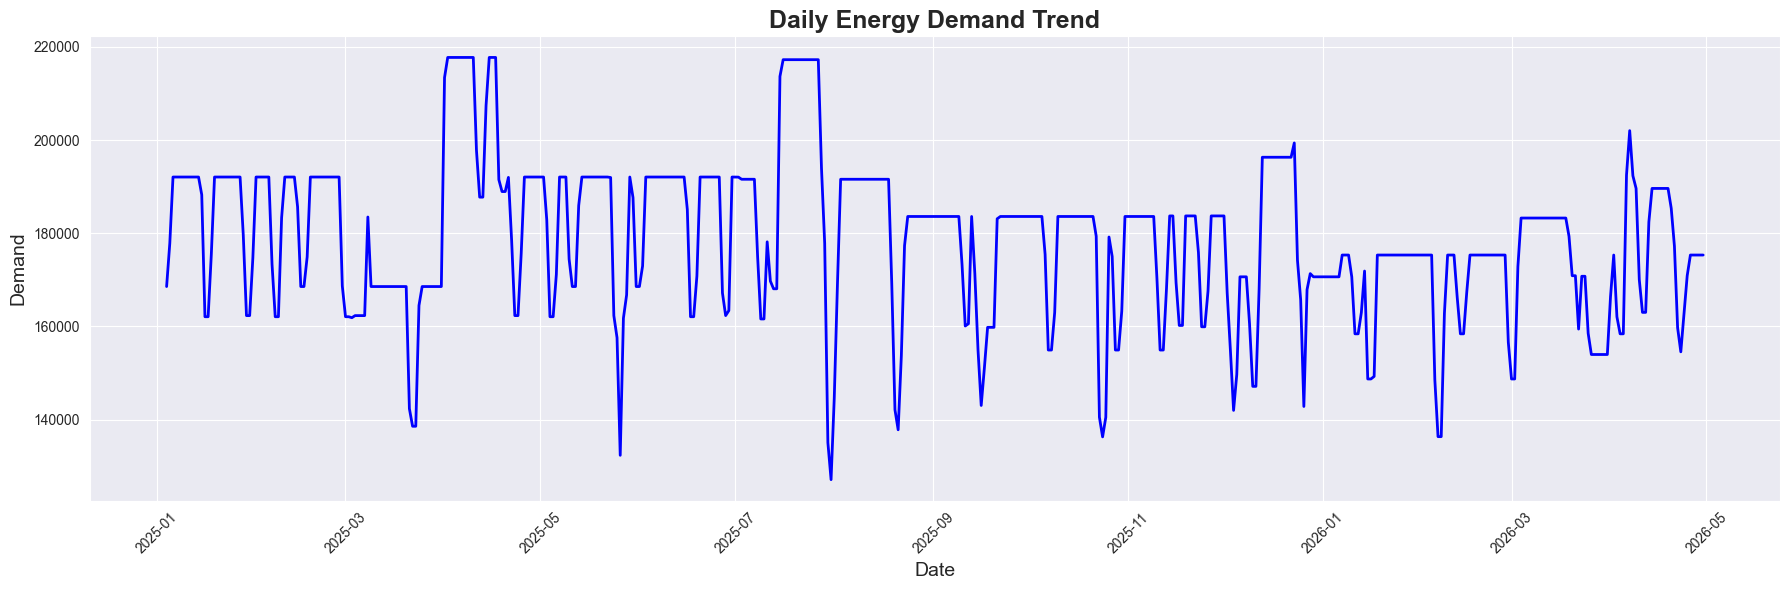

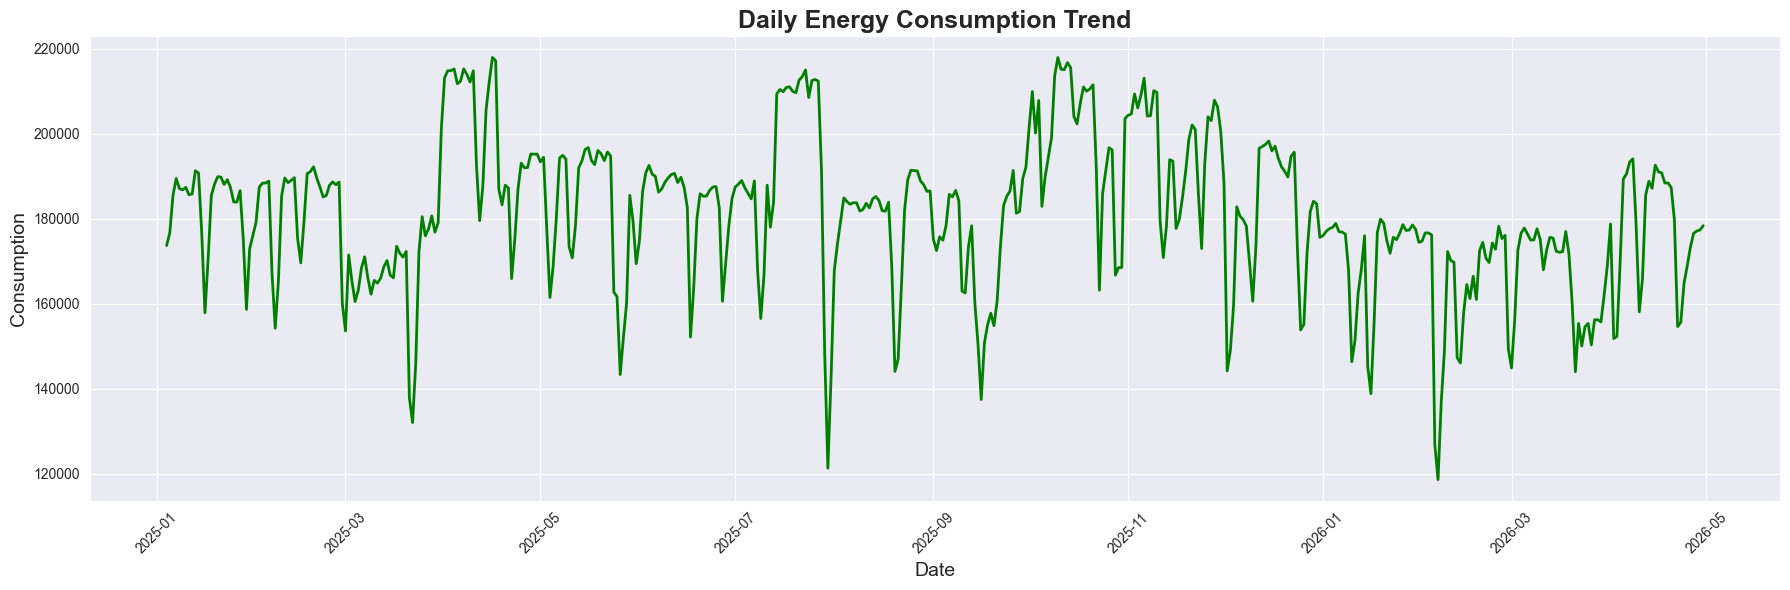

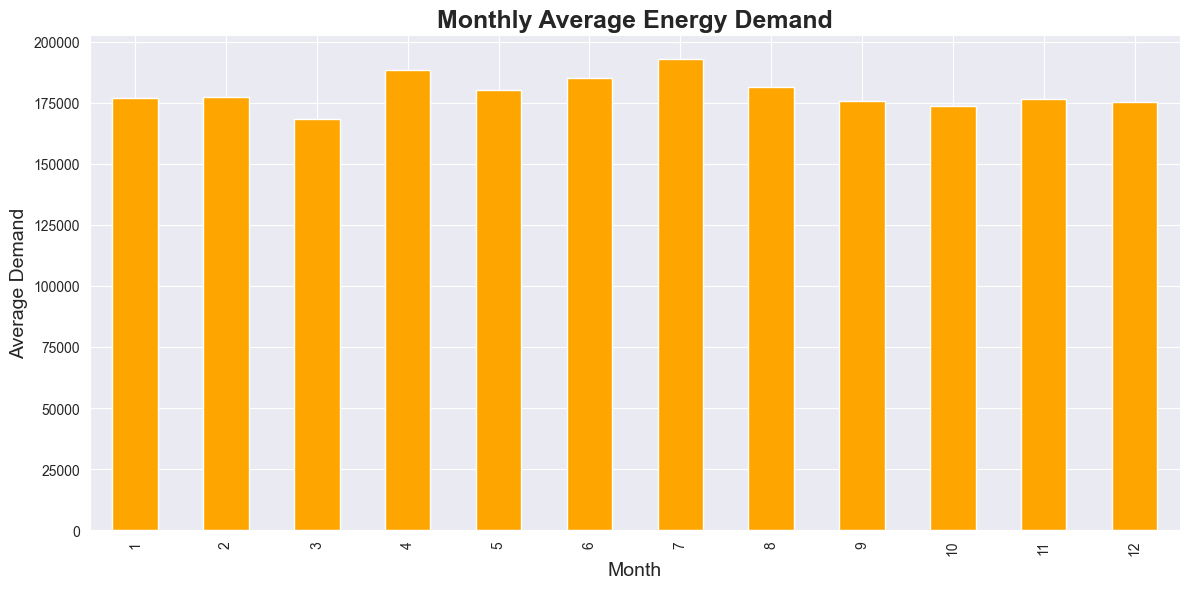

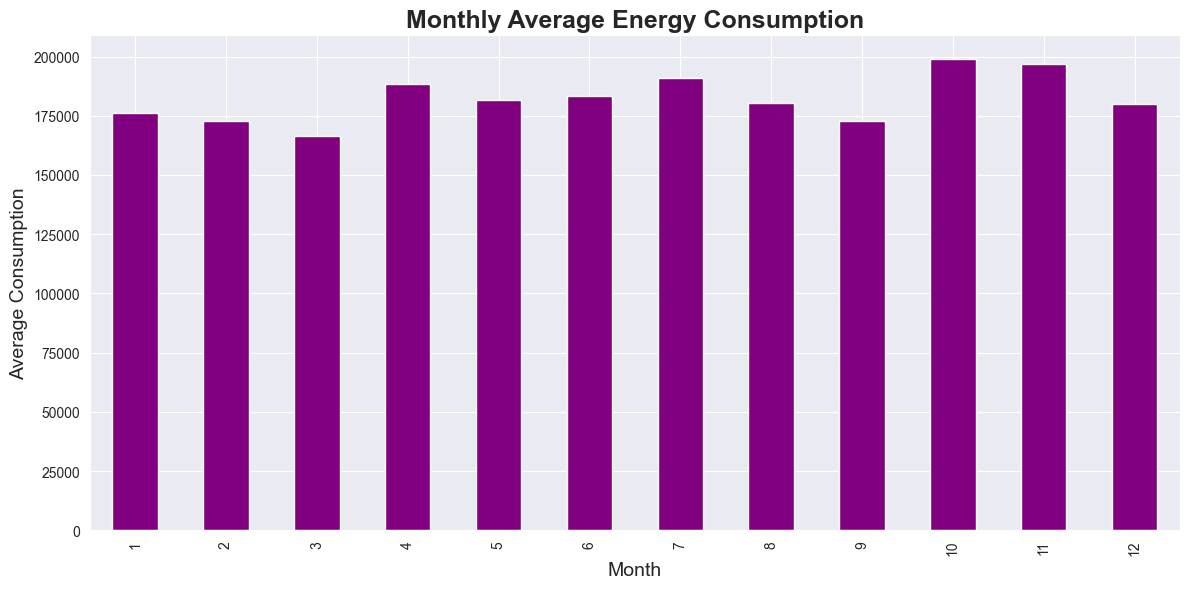

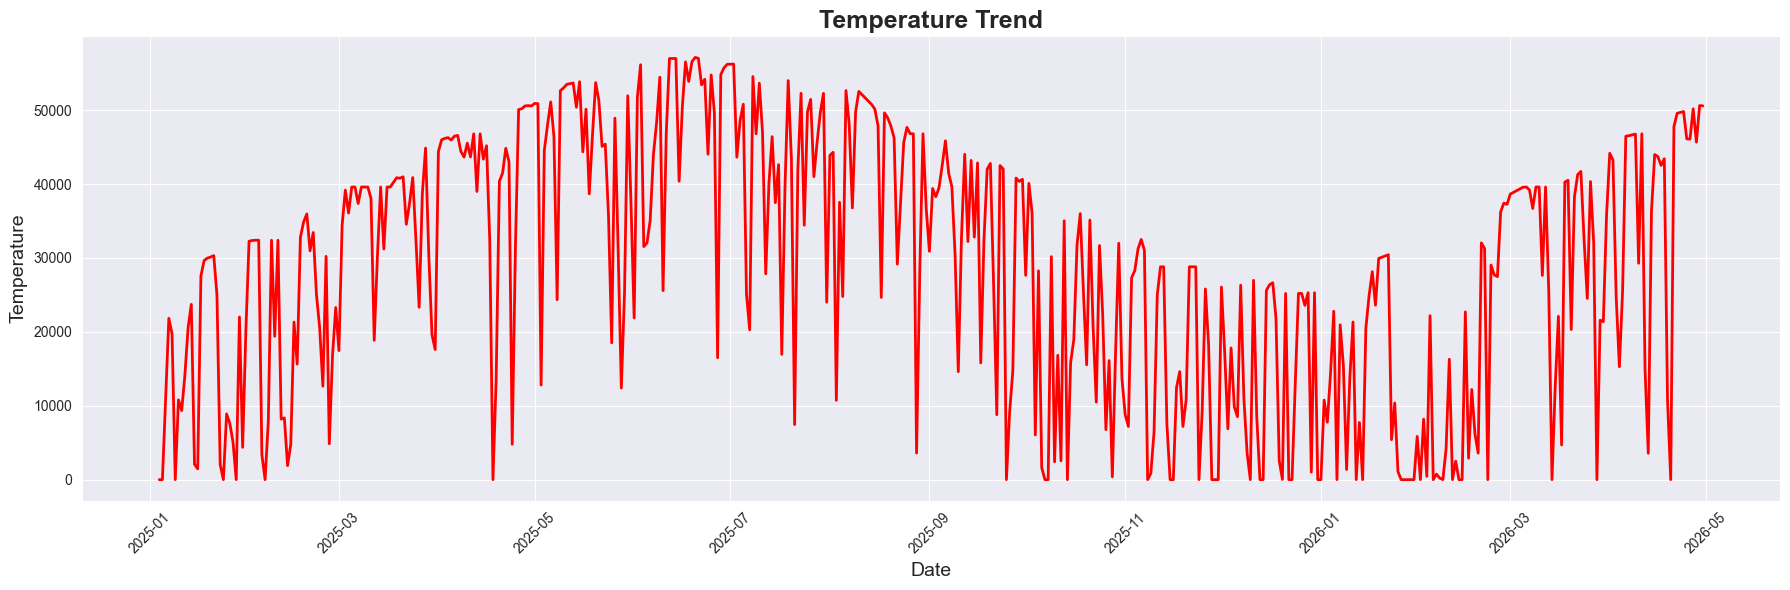

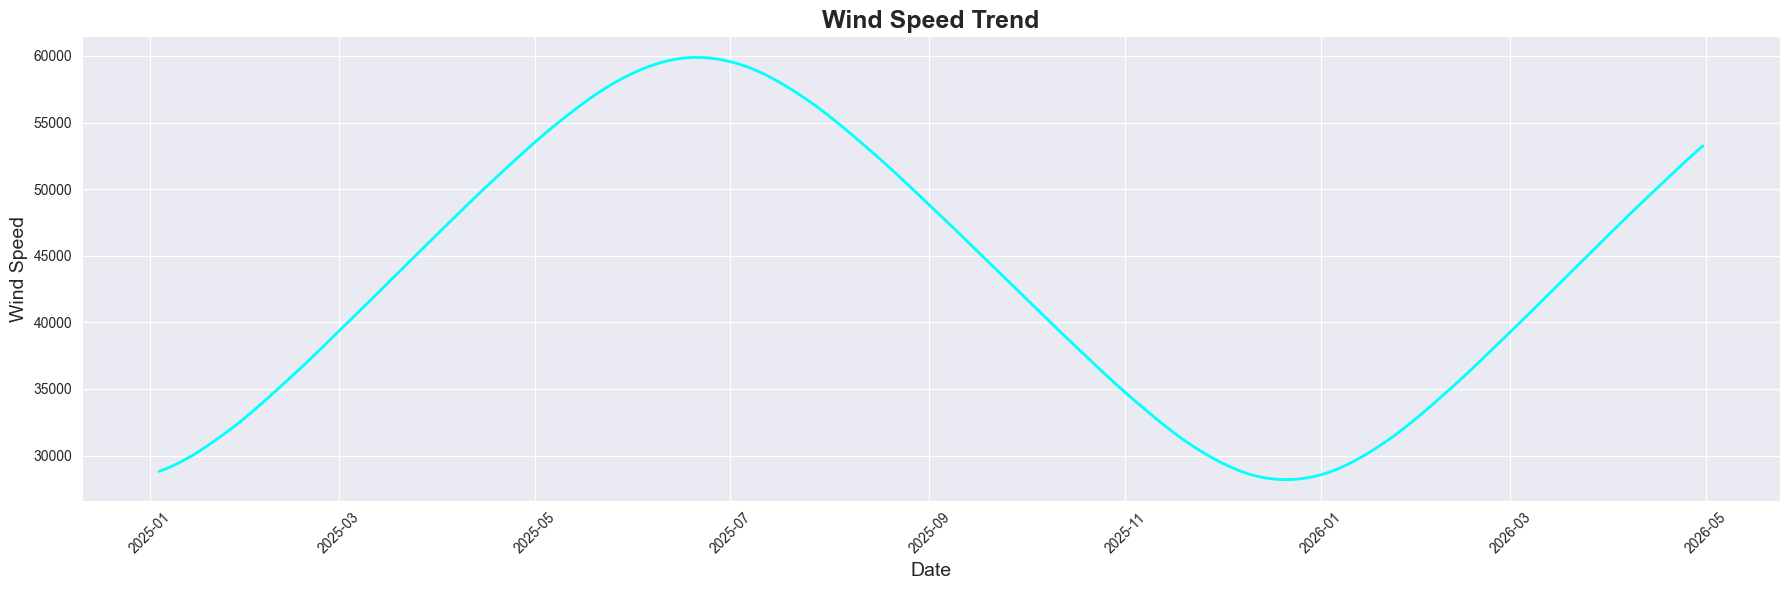

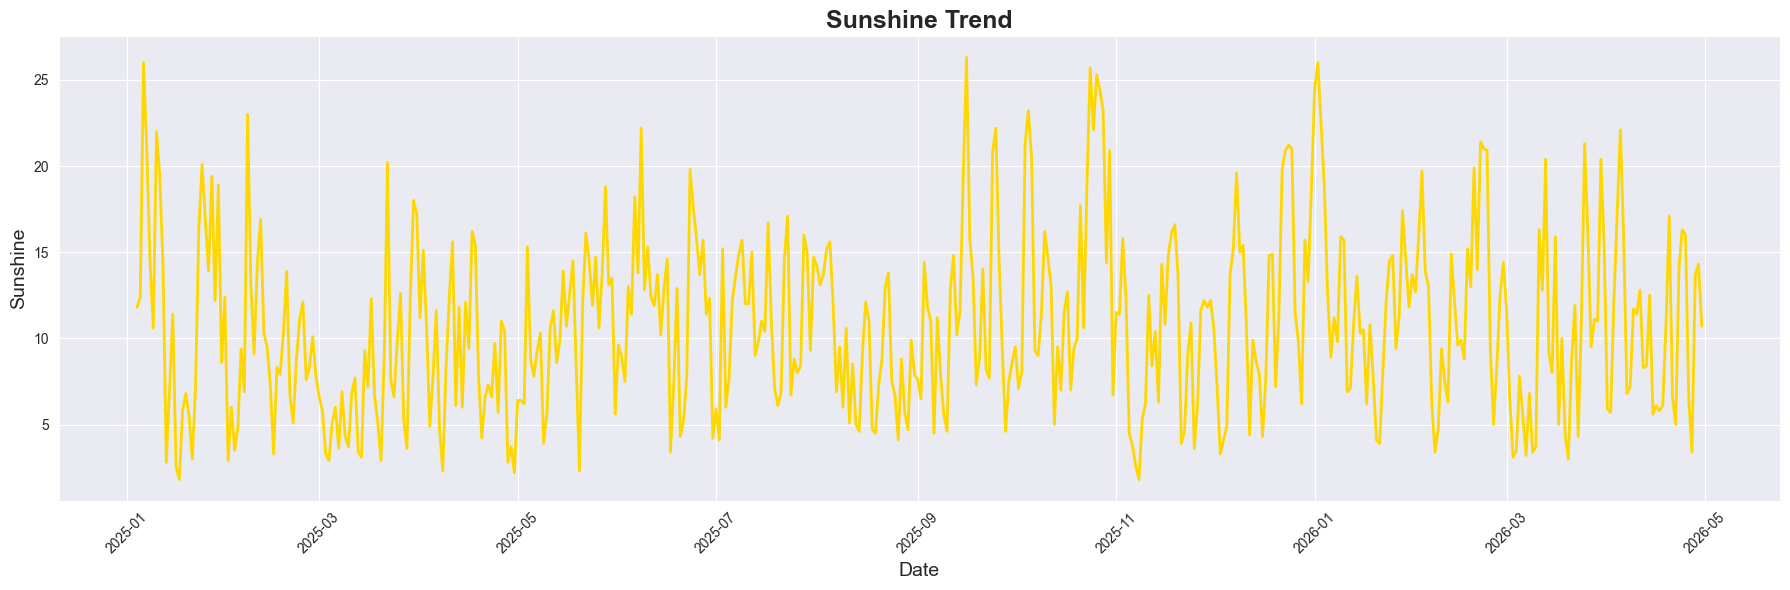

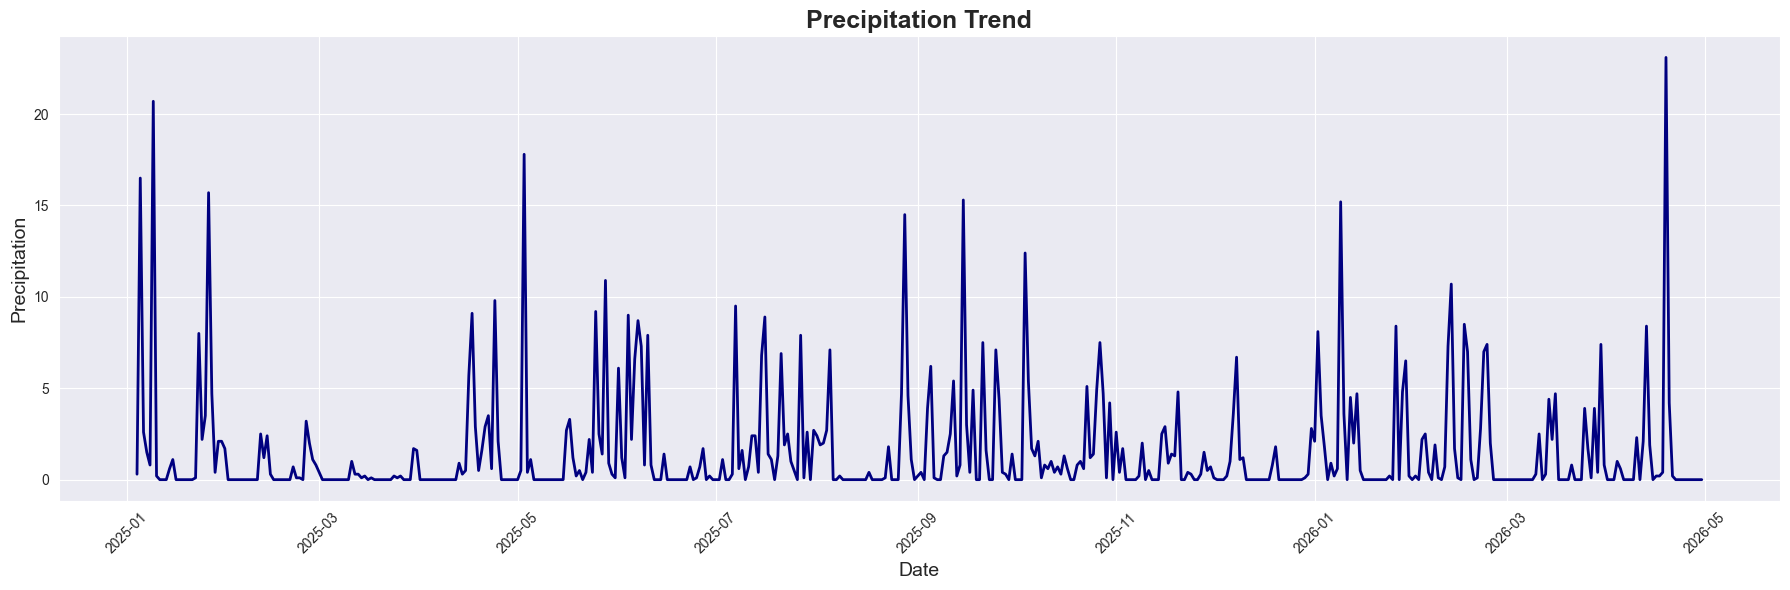

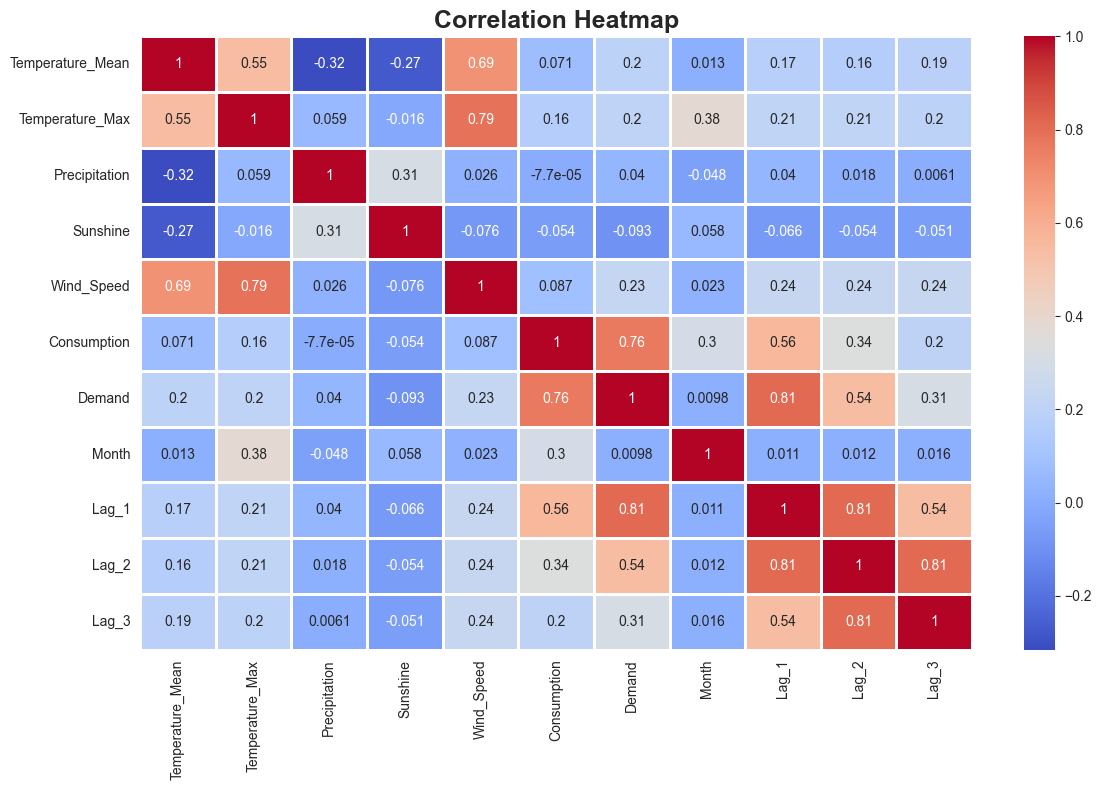

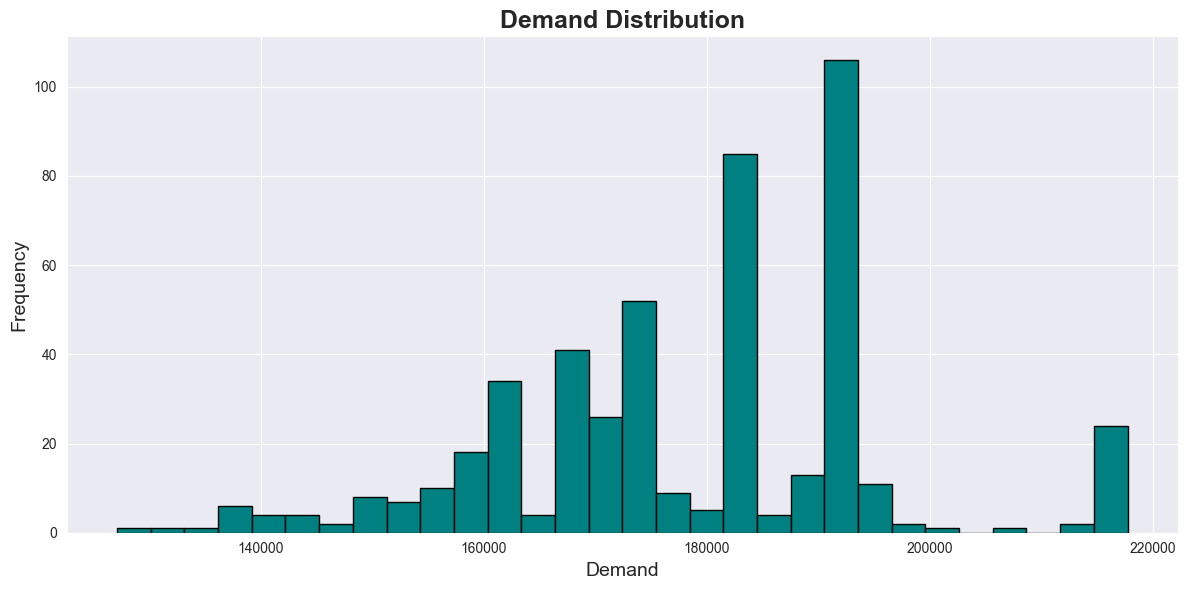

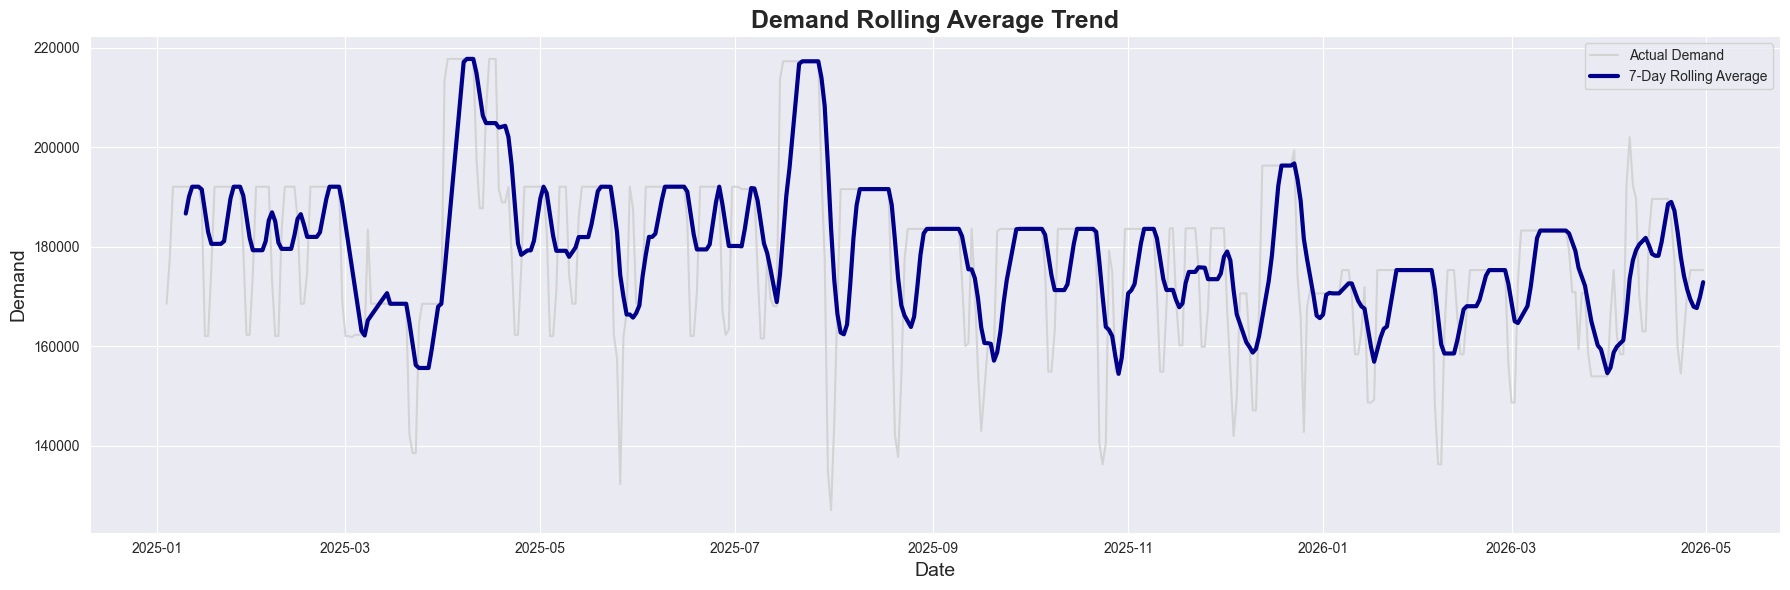

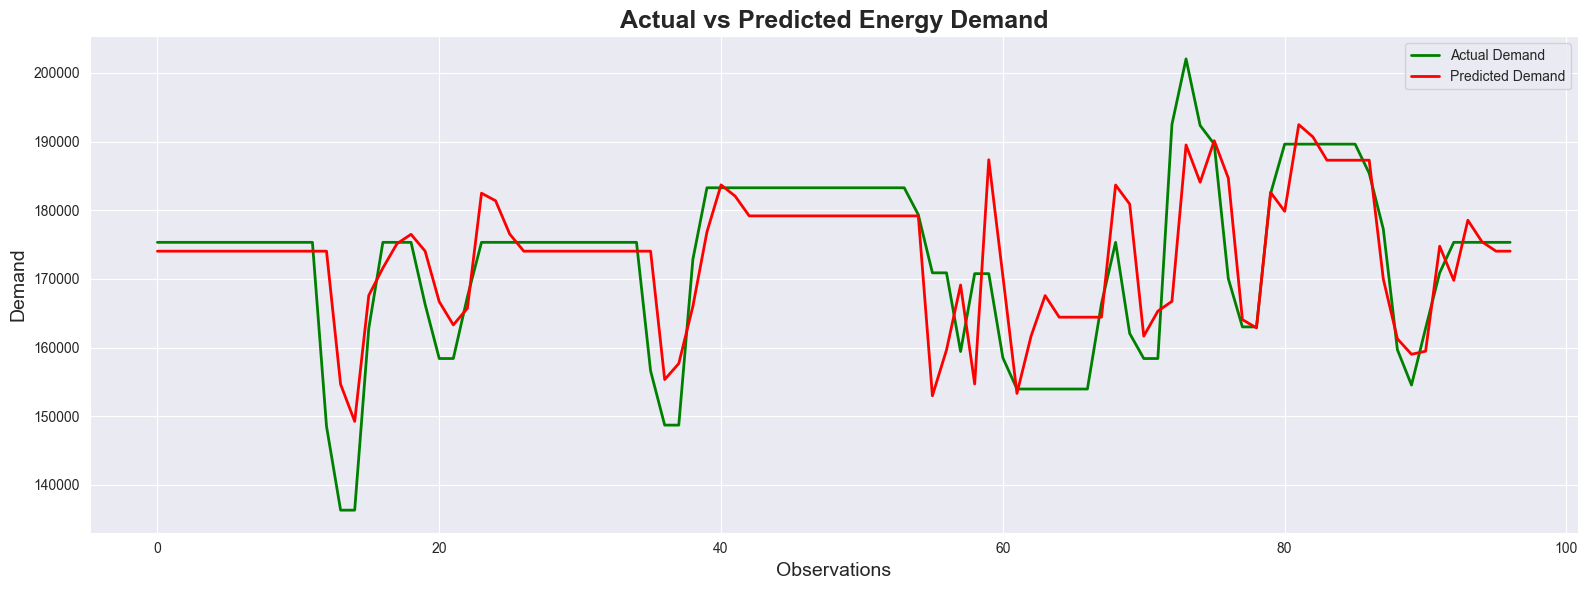

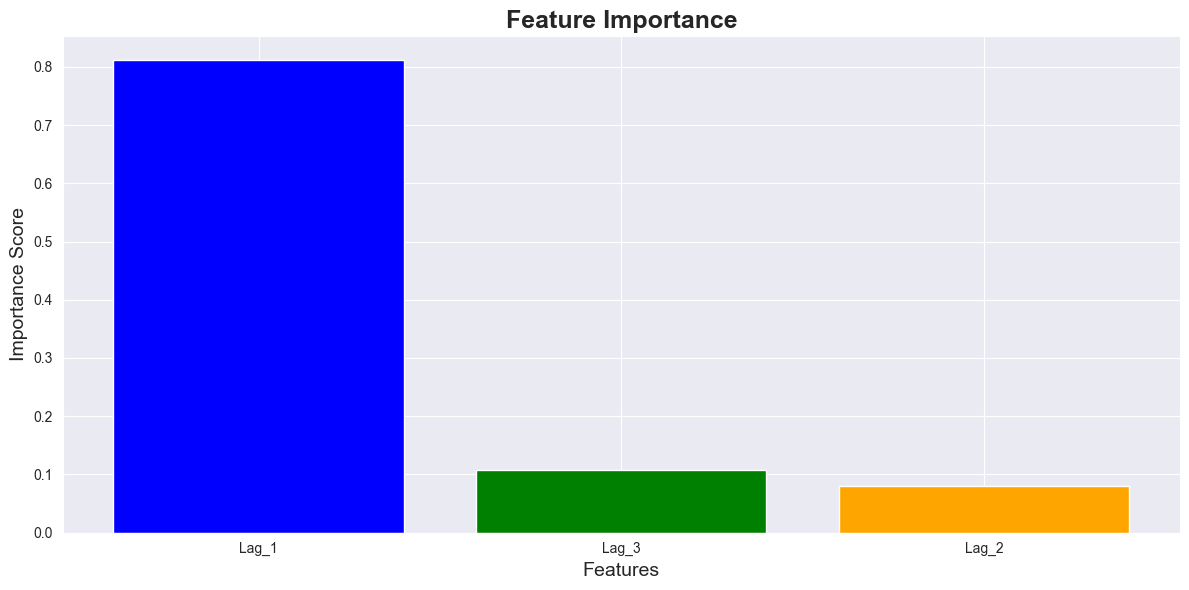

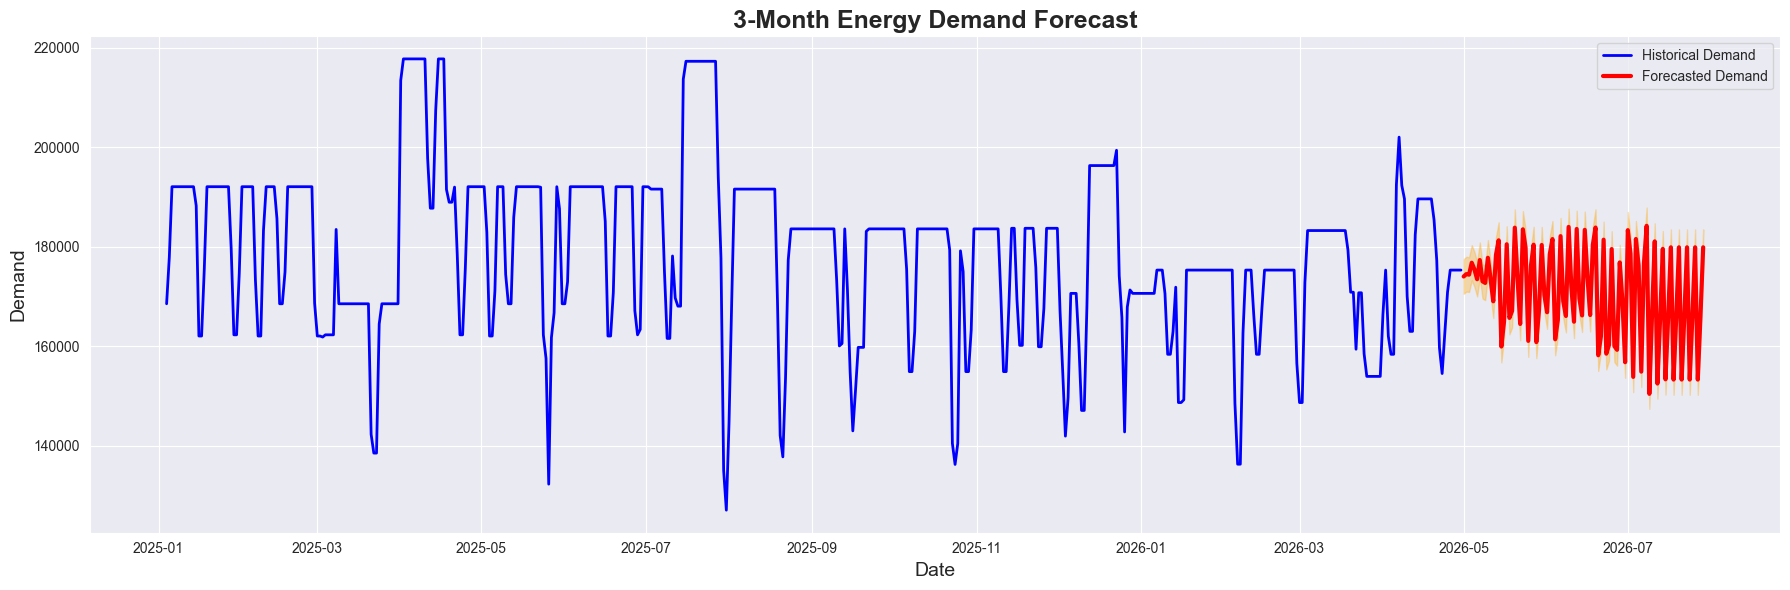

In [41]:
# =========================================================
# PROFESSIONAL COLORFUL GRAPHS FOR MBA PROJECT
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Better graph style
sns.set_style("darkgrid")

# =========================================================
# 1. DAILY ENERGY DEMAND TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Demand"],
    color="blue",
    linewidth=2
)

plt.title(
    "Daily Energy Demand Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Demand", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 2. DAILY ENERGY CONSUMPTION TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Consumption"],
    color="green",
    linewidth=2
)

plt.title(
    "Daily Energy Consumption Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Consumption", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 3. MONTHLY AVERAGE DEMAND
# =========================================================

monthly_demand = df.groupby(
    df["Date"].dt.month
)["Demand"].mean()

plt.figure(figsize=(12,6))

monthly_demand.plot(
    kind="bar",
    color="orange"
)

plt.title(
    "Monthly Average Energy Demand",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=14)

plt.ylabel("Average Demand", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 4. MONTHLY AVERAGE CONSUMPTION
# =========================================================

monthly_consumption = df.groupby(
    df["Date"].dt.month
)["Consumption"].mean()

plt.figure(figsize=(12,6))

monthly_consumption.plot(
    kind="bar",
    color="purple"
)

plt.title(
    "Monthly Average Energy Consumption",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=14)

plt.ylabel("Average Consumption", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 5. TEMPERATURE TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Temperature_Mean"],
    color="red",
    linewidth=2
)

plt.title(
    "Temperature Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Temperature", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 6. WIND SPEED TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Wind_Speed"],
    color="cyan",
    linewidth=2
)

plt.title(
    "Wind Speed Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Wind Speed", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 7. SUNSHINE TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Sunshine"],
    color="gold",
    linewidth=2
)

plt.title(
    "Sunshine Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Sunshine", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 8. PRECIPITATION TREND
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Precipitation"],
    color="navy",
    linewidth=2
)

plt.title(
    "Precipitation Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Precipitation", fontsize=14)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 9. CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(12,8))

sns.heatmap(

    df.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm",

    linewidths=1

)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# =========================================================
# 10. DEMAND DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,6))

plt.hist(
    df["Demand"],
    bins=30,
    color="teal",
    edgecolor="black"
)

plt.title(
    "Demand Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Demand", fontsize=14)

plt.ylabel("Frequency", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 11. 7-DAY ROLLING AVERAGE
# =========================================================

df["Rolling_Avg"] = df["Demand"].rolling(
    window=7
).mean()

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Demand"],
    color="lightgray",
    label="Actual Demand"
)

plt.plot(
    df["Date"],
    df["Rolling_Avg"],
    color="darkblue",
    linewidth=3,
    label="7-Day Rolling Average"
)

plt.title(
    "Demand Rolling Average Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Demand", fontsize=14)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 12. ACTUAL VS PREDICTED DEMAND
# =========================================================

plt.figure(figsize=(16,6))

plt.plot(
    y_test.values,
    color="green",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    y_pred,
    color="red",
    linewidth=2,
    label="Predicted Demand"
)

plt.title(
    "Actual vs Predicted Energy Demand",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Observations", fontsize=14)

plt.ylabel("Demand", fontsize=14)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 13. FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(

    importance["Feature"],

    importance["Importance"],

    color=[
        "blue",
        "green",
        "orange",
        "purple",
        "red",
        "cyan"
    ]

)

plt.title(
    "Feature Importance",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Features", fontsize=14)

plt.ylabel("Importance Score", fontsize=14)

plt.grid(True)

plt.tight_layout()

plt.show()

# =========================================================
# 14. 3-MONTH FORECAST GRAPH
# =========================================================

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["Demand"],
    color="blue",
    linewidth=2,
    label="Historical Demand"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Demand"],
    color="red",
    linewidth=3,
    label="Forecasted Demand"
)

plt.fill_between(

    forecast_df["Date"],

    forecast_df["Forecasted_Demand"] * 0.98,

    forecast_df["Forecasted_Demand"] * 1.02,

    color="orange",

    alpha=0.3

)

plt.title(
    "3-Month Energy Demand Forecast",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=14)

plt.ylabel("Demand", fontsize=14)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

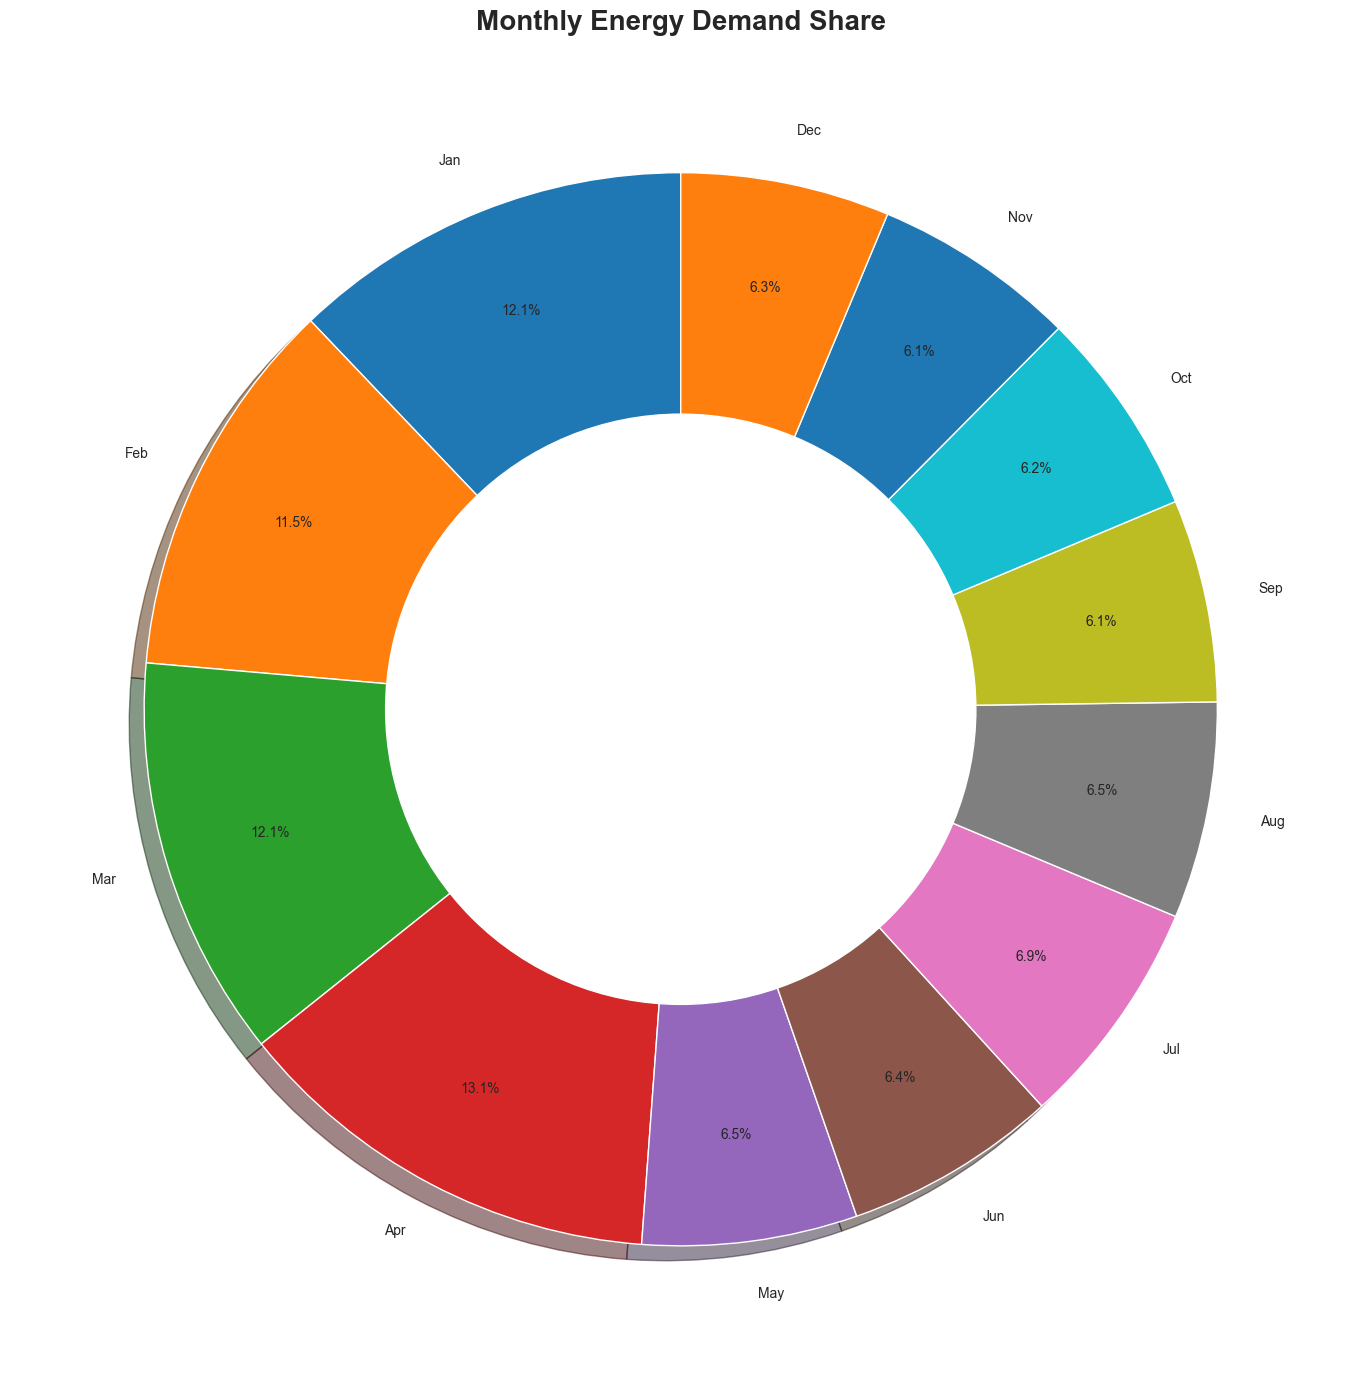

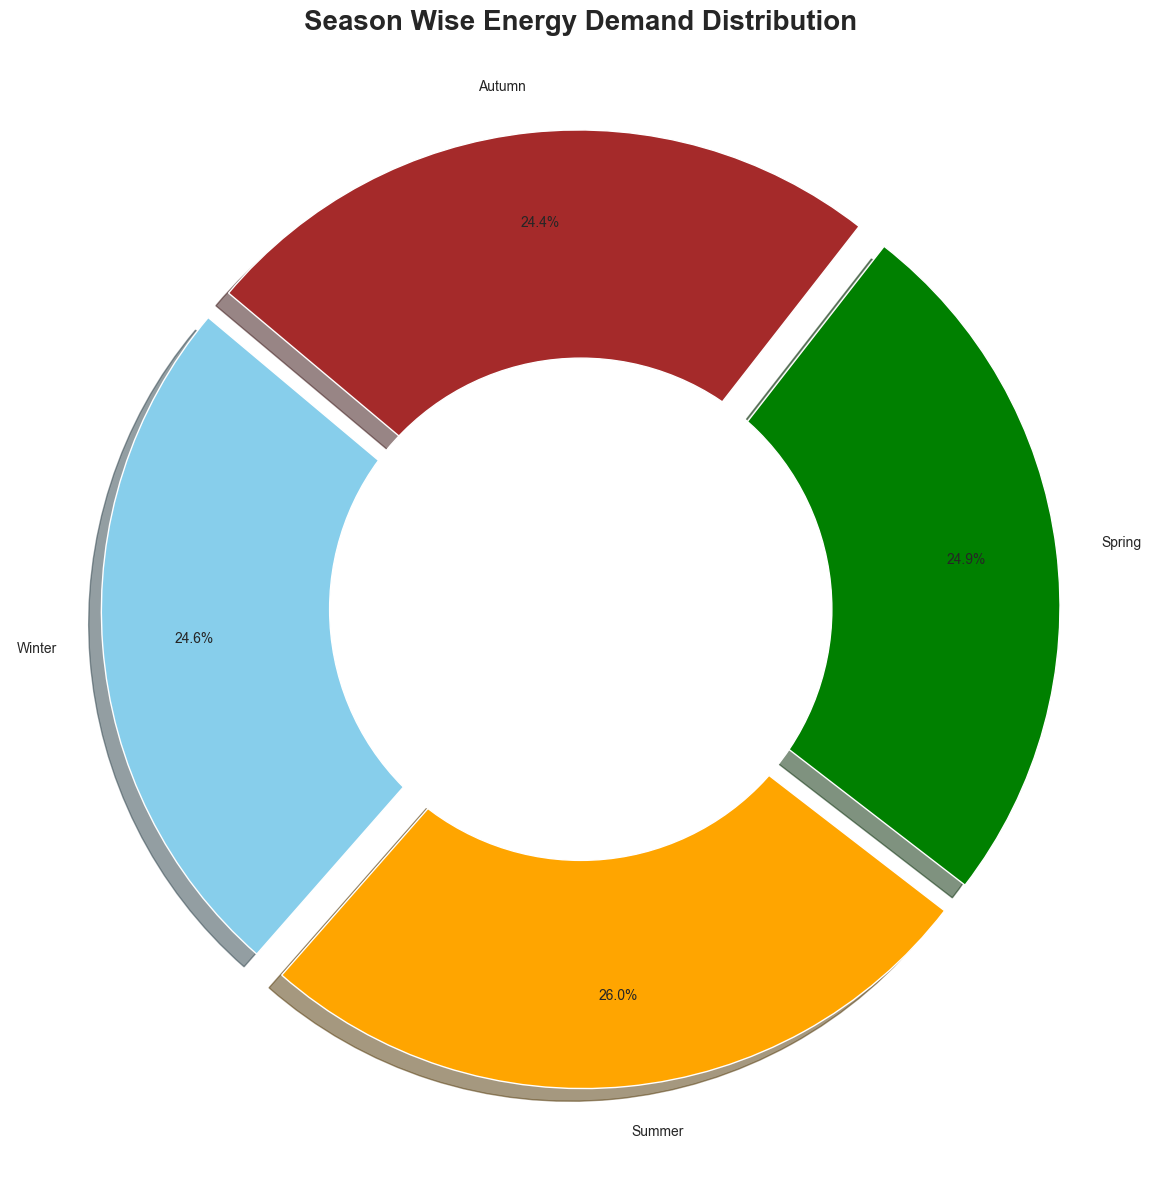

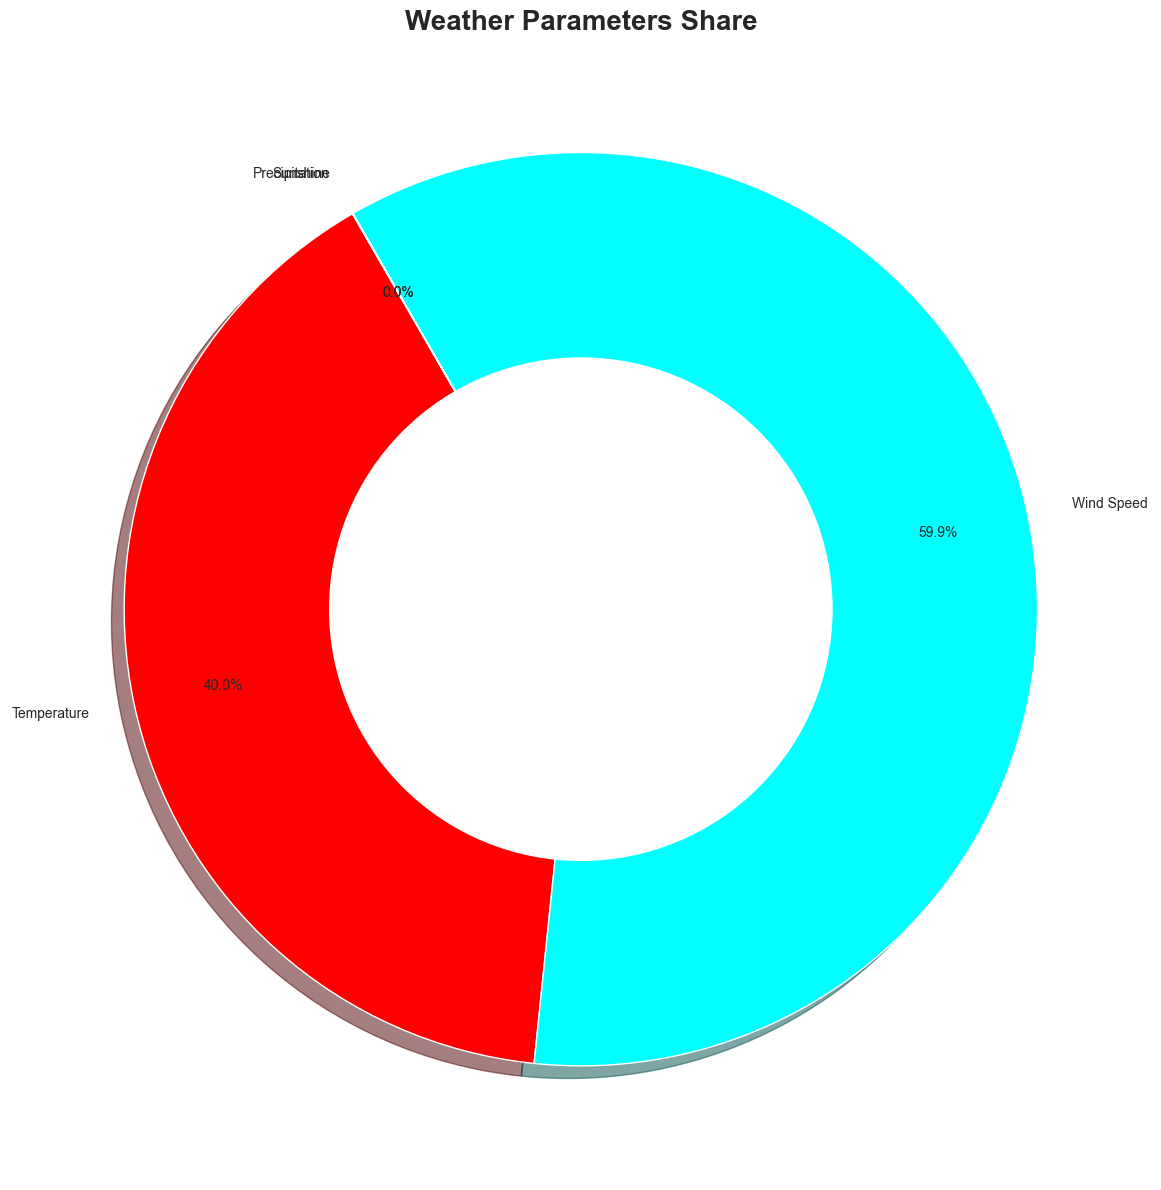

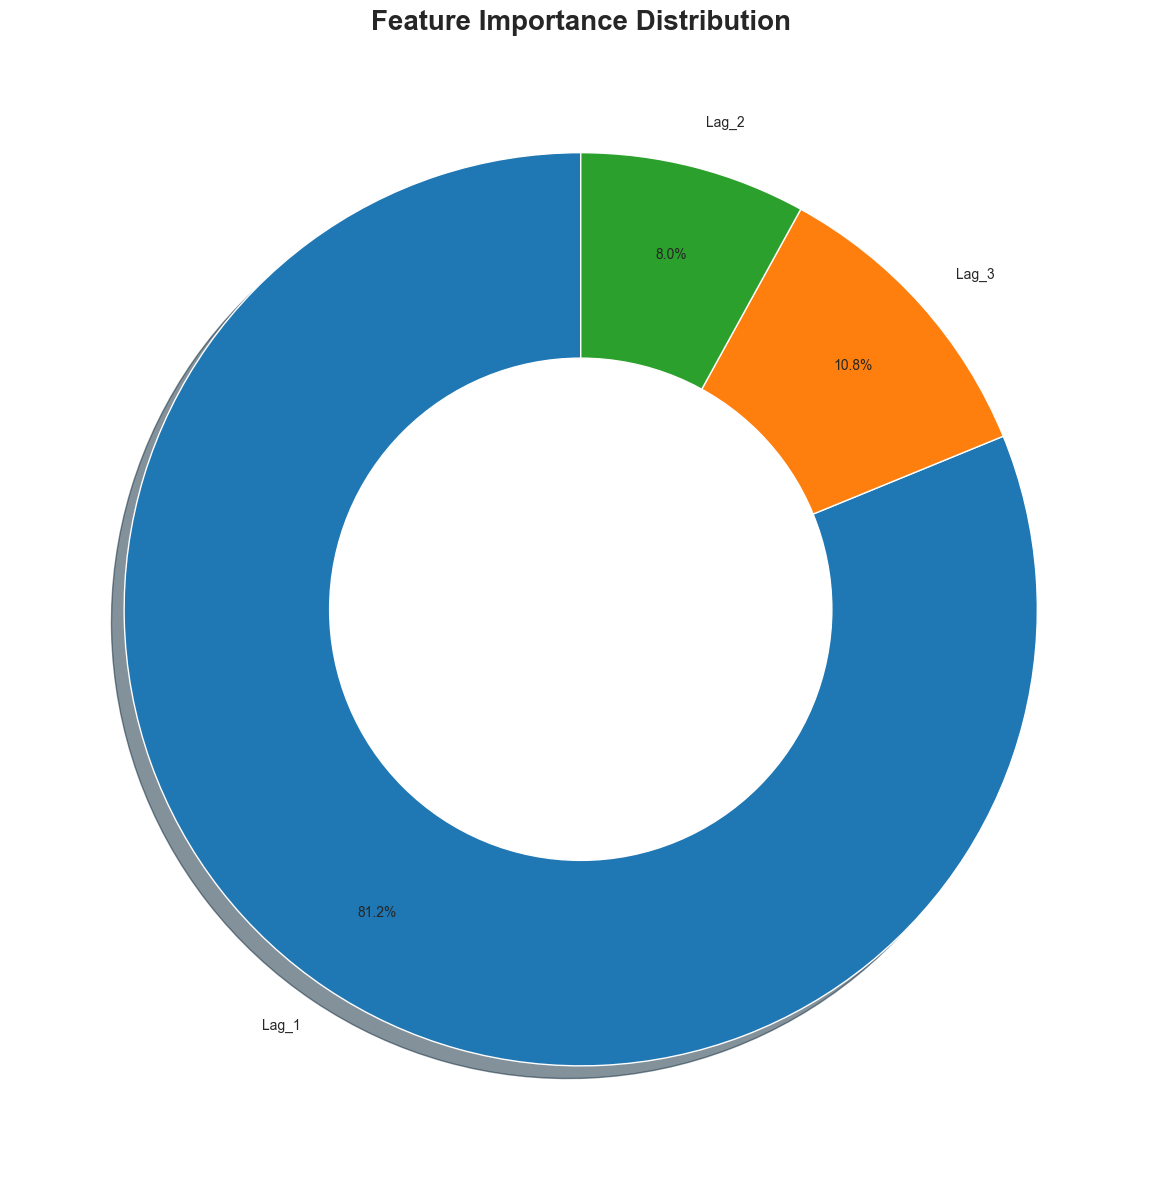

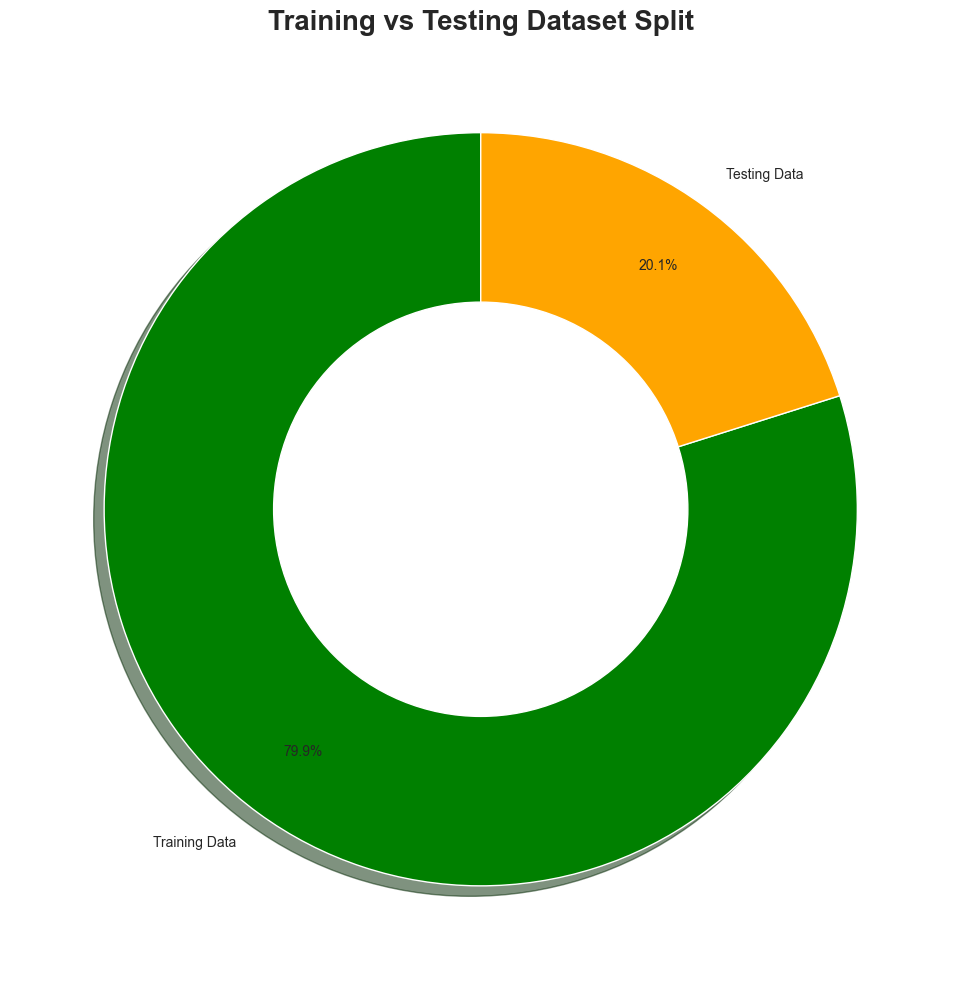

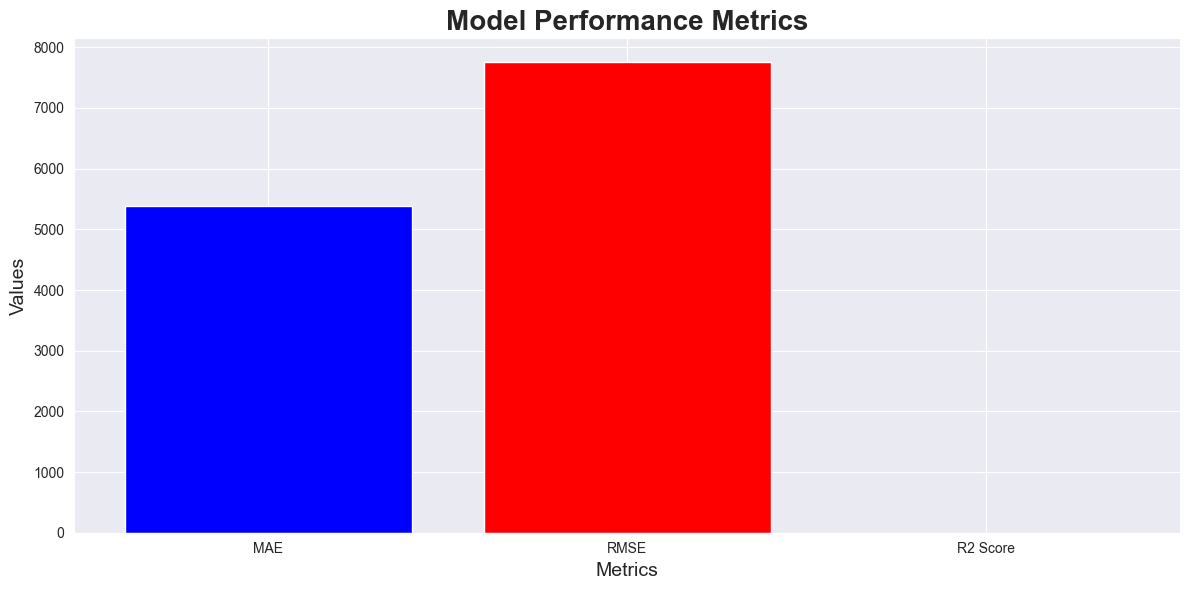

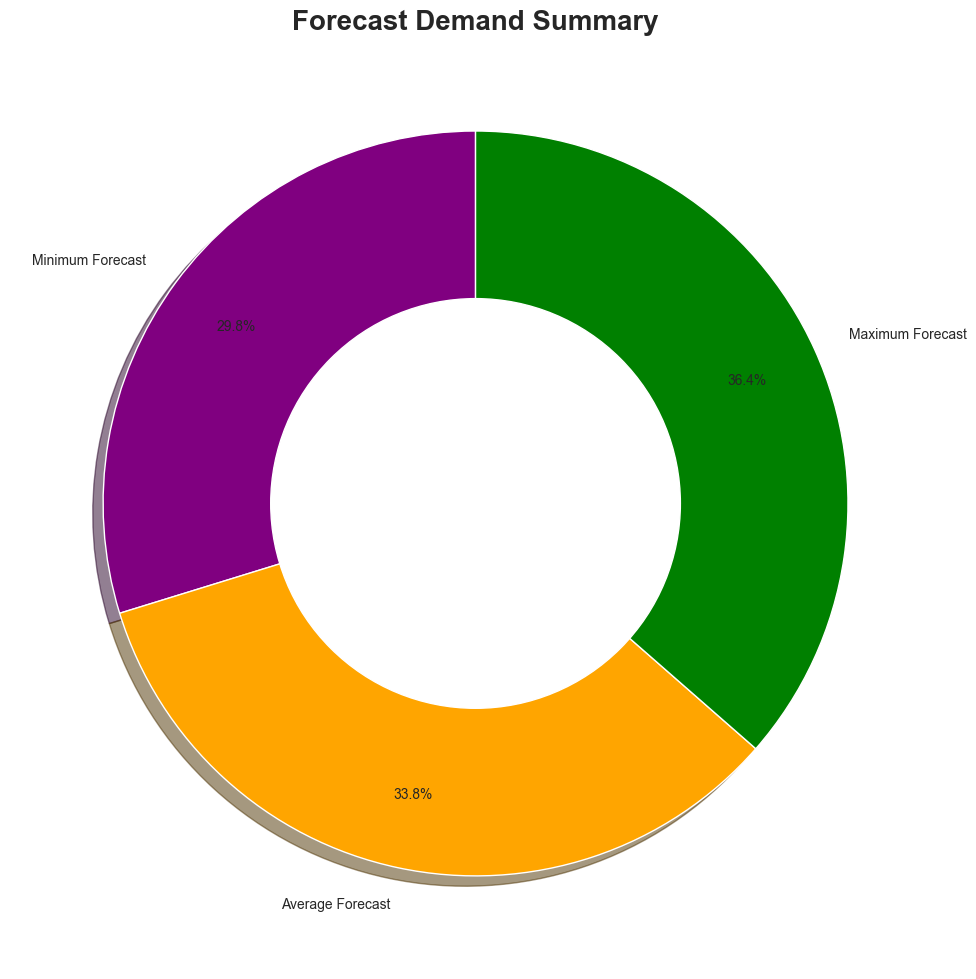

In [43]:
# =========================================================
# UPDATED PROFESSIONAL PIE / DONUT CHARTS
# NO OVERLAPPING LABELS
# MBA PROJECT READY
# =========================================================

import matplotlib.pyplot as plt

# =========================================================
# GLOBAL SETTINGS
# =========================================================

plt.rcParams["figure.autolayout"] = True

# =========================================================
# 1. MONTHLY ENERGY DEMAND SHARE
# DONUT CHART
# =========================================================

monthly_share = df.groupby(
    df["Date"].dt.month
)["Demand"].sum()

month_labels = [

    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"

]

plt.figure(figsize=(14,14))

wedges, texts, autotexts = plt.pie(

    monthly_share,

    labels=month_labels,

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.8,

    labeldistance=1.1,

    shadow=True

)

# DONUT CENTER
centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Monthly Energy Demand Share",

    fontsize=20,

    fontweight="bold"

)

plt.show()

# =========================================================
# 2. SEASON WISE DEMAND SHARE
# =========================================================

winter = df[
    df["Date"].dt.month.isin([12,1,2])
]["Demand"].mean()

summer = df[
    df["Date"].dt.month.isin([6,7,8])
]["Demand"].mean()

spring = df[
    df["Date"].dt.month.isin([3,4,5])
]["Demand"].mean()

autumn = df[
    df["Date"].dt.month.isin([9,10,11])
]["Demand"].mean()

season_labels = [

    "Winter",
    "Summer",
    "Spring",
    "Autumn"

]

season_values = [

    winter,
    summer,
    spring,
    autumn

]

season_colors = [

    "skyblue",
    "orange",
    "green",
    "brown"

]

plt.figure(figsize=(12,12))

wedges, texts, autotexts = plt.pie(

    season_values,

    labels=season_labels,

    colors=season_colors,

    autopct='%1.1f%%',

    startangle=140,

    pctdistance=0.8,

    labeldistance=1.1,

    explode=(0.05,0.05,0.05,0.05),

    shadow=True

)

# DONUT CENTER
centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Season Wise Energy Demand Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.show()

# =========================================================
# 3. WEATHER PARAMETERS SHARE
# =========================================================

weather_labels = [

    "Temperature",
    "Wind Speed",
    "Sunshine",
    "Precipitation"

]

weather_values = [

    df["Temperature_Mean"].mean(),

    df["Wind_Speed"].mean(),

    df["Sunshine"].mean(),

    df["Precipitation"].mean()

]

weather_colors = [

    "red",
    "cyan",
    "gold",
    "navy"

]

plt.figure(figsize=(12,12))

wedges, texts, autotexts = plt.pie(

    weather_values,

    labels=weather_labels,

    colors=weather_colors,

    autopct='%1.1f%%',

    startangle=120,

    pctdistance=0.8,

    labeldistance=1.1,

    shadow=True

)

# DONUT CENTER
centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Weather Parameters Share",

    fontsize=20,

    fontweight="bold"

)

plt.show()

# =========================================================
# 4. FEATURE IMPORTANCE CHART
# =========================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,12))

wedges, texts, autotexts = plt.pie(

    importance["Importance"],

    labels=importance["Feature"],

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.8,

    labeldistance=1.1,

    shadow=True

)

# DONUT CENTER
centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Feature Importance Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.show()

# =========================================================
# 5. TRAIN VS TEST SPLIT
# =========================================================

train_size = len(X_train)

test_size = len(X_test)

sizes = [

    train_size,
    test_size

]

labels = [

    "Training Data",
    "Testing Data"

]

colors = [

    "green",
    "orange"

]

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(

    sizes,

    labels=labels,

    colors=colors,

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.8,

    labeldistance=1.1,

    shadow=True

)

# DONUT CENTER
centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Training vs Testing Dataset Split",

    fontsize=20,

    fontweight="bold"

)

plt.show()

# =========================================================
# 6. MODEL PERFORMANCE BAR CHART
# =========================================================

metrics = [

    mae,
    rmse,
    r2

]

metric_labels = [

    "MAE",
    "RMSE",
    "R2 Score"

]

metric_colors = [

    "blue",
    "red",
    "green"

]

plt.figure(figsize=(12,6))

plt.bar(

    metric_labels,

    metrics,

    color=metric_colors

)

plt.title(

    "Model Performance Metrics",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Metrics", fontsize=14)

plt.ylabel("Values", fontsize=14)

plt.grid(True)

plt.show()

# =========================================================
# 7. FORECAST SUMMARY CHART
# =========================================================

forecast_summary = [

    forecast_df["Forecasted_Demand"].min(),

    forecast_df["Forecasted_Demand"].mean(),

    forecast_df["Forecasted_Demand"].max()

]

summary_labels = [

    "Minimum Forecast",
    "Average Forecast",
    "Maximum Forecast"

]

summary_colors = [

    "purple",
    "orange",
    "green"

]

plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(

    forecast_summary,

    labels=summary_labels,

    colors=summary_colors,

    autopct='%1.1f%%',

    startangle=90,

    pctdistance=0.8,

    labeldistance=1.1,

    shadow=True

)

centre_circle = plt.Circle(

    (0,0),

    0.55,

    fc='white'

)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(

    "Forecast Demand Summary",

    fontsize=20,

    fontweight="bold"

)

plt.show()